In [ ]:
#import
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

In [ ]:
#load the dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

In [ ]:
#Preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [ ]:
#encoder
input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

In [ ]:
#decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

In [ ]:
#create model and compile
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [ ]:
#train
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

autoencoder.save("cae.keras")
autoencoder.save("convolutional_autoencoder.keras")

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 398ms/step - loss: 0.1019 - val_loss: 0.0722
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 405ms/step - loss: 0.0712 - val_loss: 0.0691
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 399ms/step - loss: 0.0690 - val_loss: 0.0678
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 407ms/step - loss: 0.0677 - val_loss: 0.0667
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 395ms/step - loss: 0.0669 - val_loss: 0.0660
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 395ms/step - loss: 0.0663 - val_loss: 0.0655
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 400ms/step - loss: 0.0658 - val_loss: 0.0652
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 408ms/step - loss: 0.0654 - val_loss: 0.0651
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 404ms/step - loss: 0.0650 - val_loss: 0.0646
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 398ms/step - loss: 0.0647 - val_loss: 0.0641
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 390ms/step - loss: 0.0645 - val_loss: 0.0639
Epoch 12

In [ ]:
#reconstruct image
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


In [ ]:
#metrics
mse_list = []
psnr_list = []
ssim_list = []

for i in range(len(x_test)):

    original = x_test[i].squeeze()
    reconstructed = decoded_imgs[i].squeeze()

    mse_value = mean_squared_error(
        original.flatten(),
        reconstructed.flatten()
    )

    psnr_value = psnr(original, reconstructed, data_range=1.0)

    ssim_value = ssim(
        original,
        reconstructed,
        data_range=1.0
    )

    mse_list.append(mse_value)
    psnr_list.append(psnr_value)
    ssim_list.append(ssim_value)

print("Average MSE :", np.mean(mse_list))
print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

Average MSE : 0.0010556526596505137
Average PSNR: 30.343092855036463
Average SSIM: 0.9900662727417532


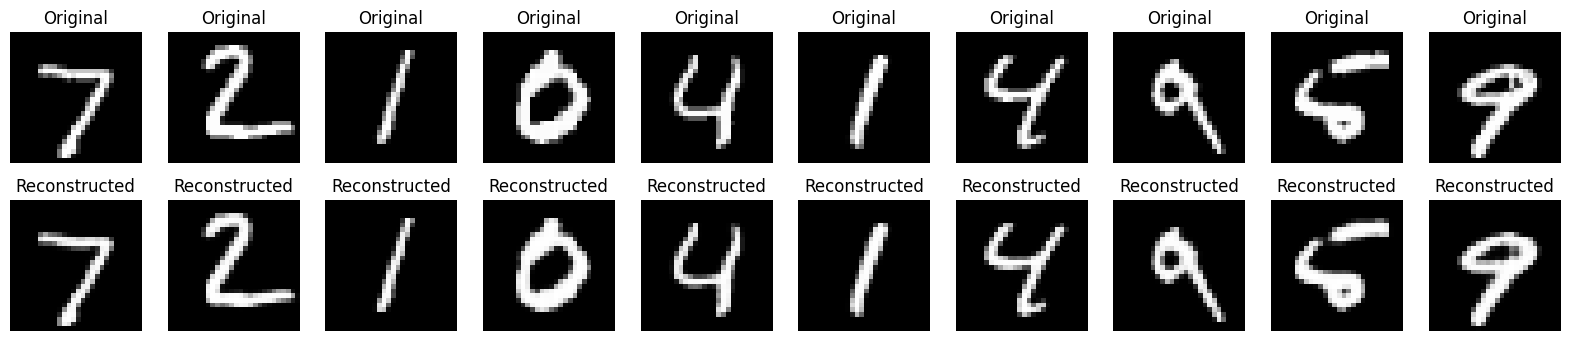

In [ ]:
#orginal vs reconstructed
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original

    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed

    plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [ ]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,493 (873.02 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 148,996 (582.02 KB)

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

print(decoded_imgs.min())
print(decoded_imgs.max())
print(decoded_imgs.mean())

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
7.323902e-21
0.99920094
0.13398118


In [ ]:
print(x_train.shape)
print(x_train.min(), x_train.max())

(60000, 28, 28, 1)
0.0 1.0


In [ ]:
print(history.history)

{'loss': [0.10194176435470581, 0.07124233990907669, 0.06898491084575653, 0.06773868948221207, 0.06689739227294922, 0.06626632809638977, 0.06577301770448685, 0.06538667529821396, 0.06504776328802109, 0.06474977731704712, 0.06449134647846222, 0.06425464153289795, 0.06405861675739288, 0.06387065351009369, 0.0636972114443779, 0.06355701386928558, 0.0634179338812828, 0.06330528110265732, 0.06318555027246475, 0.06310050189495087], 'val_loss': [0.07218591868877411, 0.0691128596663475, 0.06780745834112167, 0.06668386608362198, 0.0659913718700409, 0.06548888236284256, 0.06518065184354782, 0.06511315703392029, 0.06456346064805984, 0.06414543092250824, 0.0639369785785675, 0.06384126842021942, 0.06352782994508743, 0.06344360113143921, 0.06338459998369217, 0.06311219185590744, 0.06296597421169281, 0.06291250884532928, 0.06273446977138519, 0.06270246207714081]}


In [ ]:
print(tf.__version__)

2.20.0
